In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import os

def find_file(filename, search_path):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

# 1. Automatically locate the file anywhere in your project
filename = "kenya.csv"
# We search starting from two levels up to be safe
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
file_path = find_file(filename, project_root)

if file_path:
    print(f"Found it! Loading from: {file_path}")
    df = pd.read_csv(file_path)
else:
    # Last resort: list everything so we can see where it is
    print("Files in current folder:", os.listdir("."))
    raise FileNotFoundError(f"I searched everywhere but couldn't find {filename}. Is it spelled exactly like that?")

# 2. Add Country & Clean NASA Sentinel Values
df['Country'] = 'Kenya'
df.replace(-999, np.nan, inplace=True)

# 3. Date Parsing
# NASA uses YEAR and Day of Year (DOY). 
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

# 4. Outlier Detection (Z-score > 3)
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR']
df_numeric = df[cols_to_check].dropna()
z_scores = np.abs(stats.zscore(df_numeric))

print("\n--- Success! Kenya Data Profiled ---")
print(f"Total rows: {len(df)}")
print(f"Outlier Counts (|Z| > 3):\n{(z_scores > 3).sum()}")

# 5. Export Clean Data to a safe spot
df.to_csv("kenya_clean.csv", index=False)
df.head()

Found it! Loading from: c:\Users\HP\Desktop\10acadamey\week0\-climate-challenge-week0\.github\workflows\kenya.csv

--- Success! Kenya Data Profiled ---
Total rows: 4108
Outlier Counts (|Z| > 3):
112


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


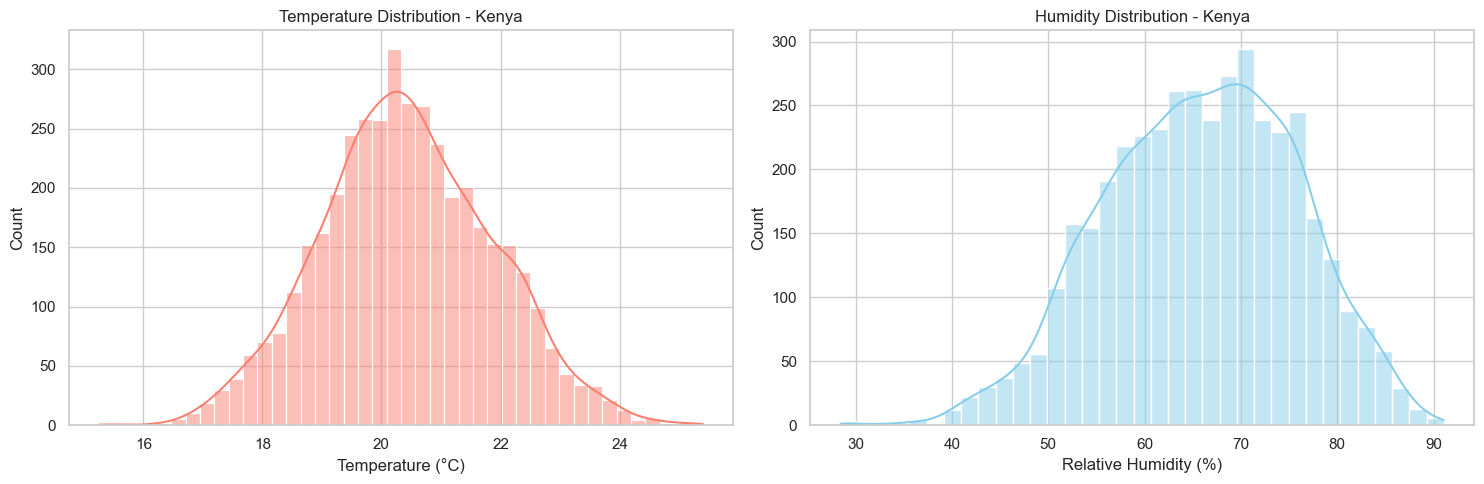

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a figure for distributions
plt.figure(figsize=(15, 5))

# Plot 1: Temperature Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['T2M'], kde=True, color='salmon')
plt.title(f'Temperature Distribution - {df["Country"].iloc[0]}')
plt.xlabel('Temperature (°C)')

# Plot 2: Humidity Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['RH2M'], kde=True, color='skyblue')
plt.title(f'Humidity Distribution - {df["Country"].iloc[0]}')
plt.xlabel('Relative Humidity (%)')

plt.tight_layout()
plt.show()

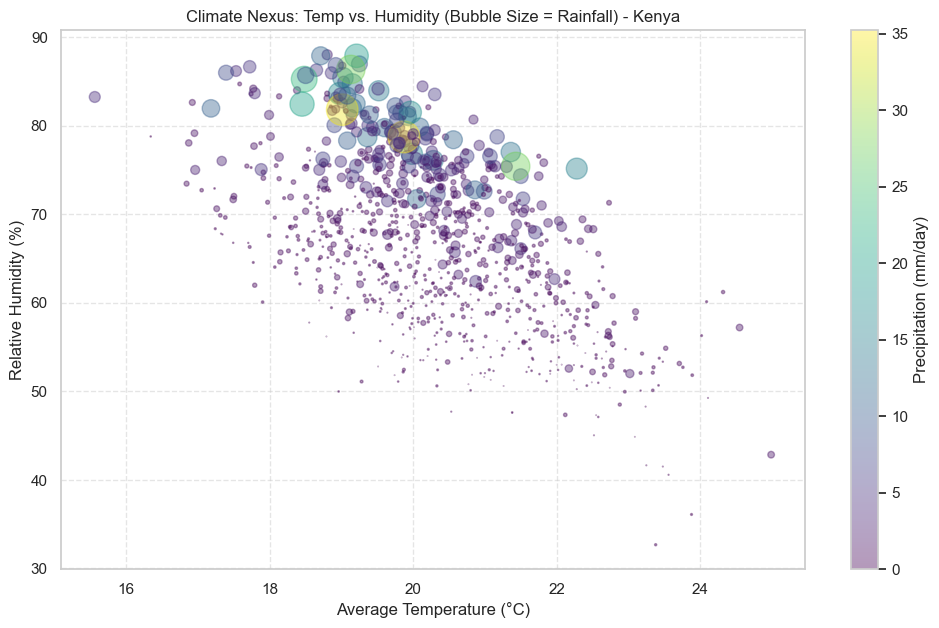

In [3]:
plt.figure(figsize=(12, 7))

# Sample data if it's too large to keep the plot clean
plot_df = df.sample(n=min(1000, len(df)))

scatter = plt.scatter(
    plot_df['T2M'], 
    plot_df['RH2M'], 
    s=plot_df['PRECTOTCORR'] * 15,  # Bubble size = Rainfall
    alpha=0.4, 
    c=plot_df['PRECTOTCORR'],      # Color also = Rainfall
    cmap='viridis'
)

plt.colorbar(scatter, label='Precipitation (mm/day)')
plt.title(f'Climate Nexus: Temp vs. Humidity (Bubble Size = Rainfall) - {df["Country"].iloc[0]}')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- Loading data from ../.github/workflows ---
✅ Found ethiopia.csv
✅ Found kenya.csv
✅ Found nigeria.csv
✅ Found sudan.csv
✅ Found tanzania.csv


C:\Users\HP\AppData\Local\Temp\ipykernel_21432\3927928194.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = combined_df.groupby('Country')['T2M'].resample('M').mean().reset_index()


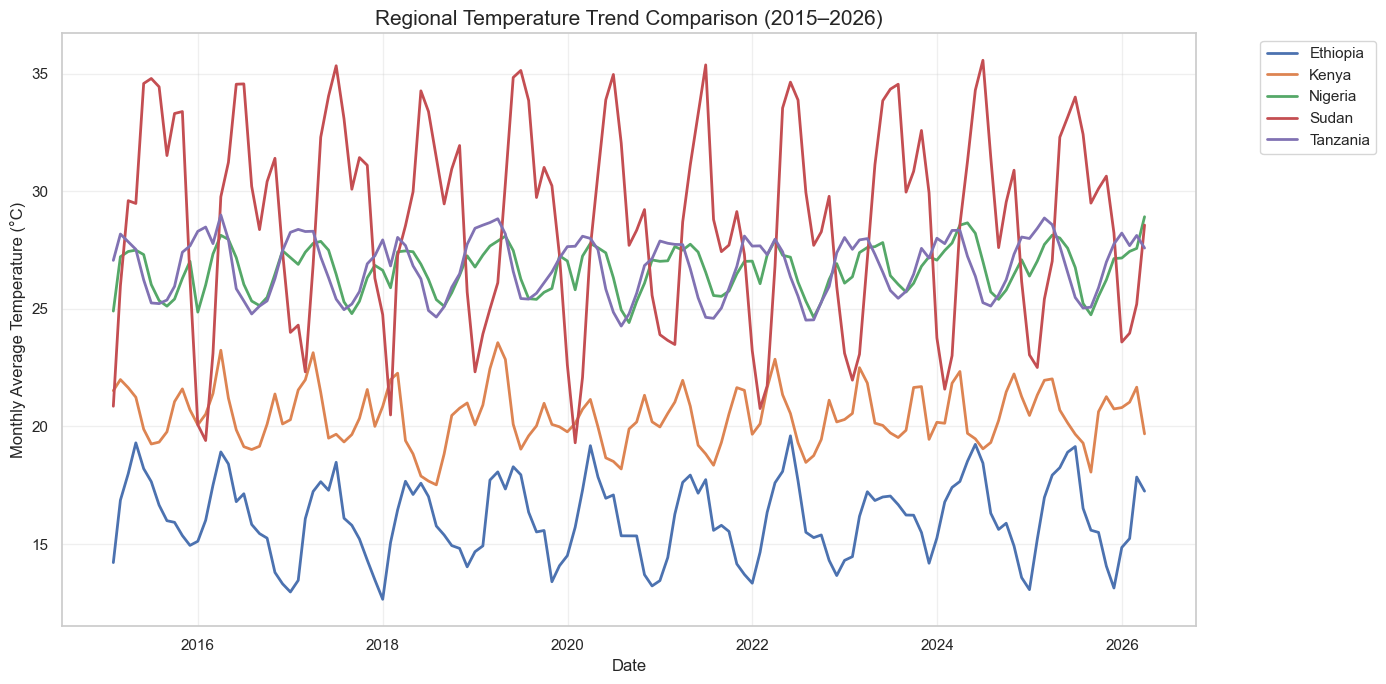


--- Temperature Summary Statistics ---
           mean  median   std
Country                      
Ethiopia  16.07   16.04  1.90
Kenya     20.43   20.36  1.44
Nigeria   26.66   26.82  1.12
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. THE SEARCH: Targeting exactly where your sidebar shows the files
possible_folders = [
    ".github/workflows",     # Root-relative
    "../.github/workflows"   # Notebook-relative
]

countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_dfs = []
valid_path = None

for folder in possible_folders:
    if os.path.exists(folder):
        valid_path = folder
        break

if not valid_path:
    raise FileNotFoundError("Could not locate the .github/workflows folder.")

# 2. LOAD DATA
print(f"--- Loading data from {valid_path} ---")
for country in countries:
    file_path = os.path.join(valid_path, f"{country}.csv")
    if os.path.exists(file_path):
        print(f"✅ Found {country}.csv")
        temp_df = pd.read_csv(file_path)
        temp_df['Country'] = country.capitalize()
        # Clean NASA data
        temp_df.replace(-999, pd.NA, inplace=True)
        # Parse Dates
        temp_df['Date'] = pd.to_datetime(temp_df['YEAR'] * 1000 + temp_df['DOY'], format='%Y%j')
        all_dfs.append(temp_df)
    else:
        print(f"❌ Missing: {country}.csv")

# 3. ANALYSIS & PLOTTING
if len(all_dfs) > 0:
    combined_df = pd.concat(all_dfs)
    combined_df.set_index('Date', inplace=True)
    
    # Calculate Monthly Average
    monthly_temp = combined_df.groupby('Country')['T2M'].resample('M').mean().reset_index()

    # Create Line Chart
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=monthly_temp, x='Date', y='T2M', hue='Country', linewidth=2)
    plt.title('Regional Temperature Trend Comparison (2015–2026)', fontsize=15)
    plt.ylabel('Monthly Average Temperature (°C)')
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Create Stats Table
    print("\n--- Temperature Summary Statistics ---")
    summary = combined_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
    print(summary)
else:
    print("🚨 No dataframes were loaded. Please check the filenames in your sidebar!")

C:\Users\HP\AppData\Local\Temp\ipykernel_21432\1806601483.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', palette='Blues')


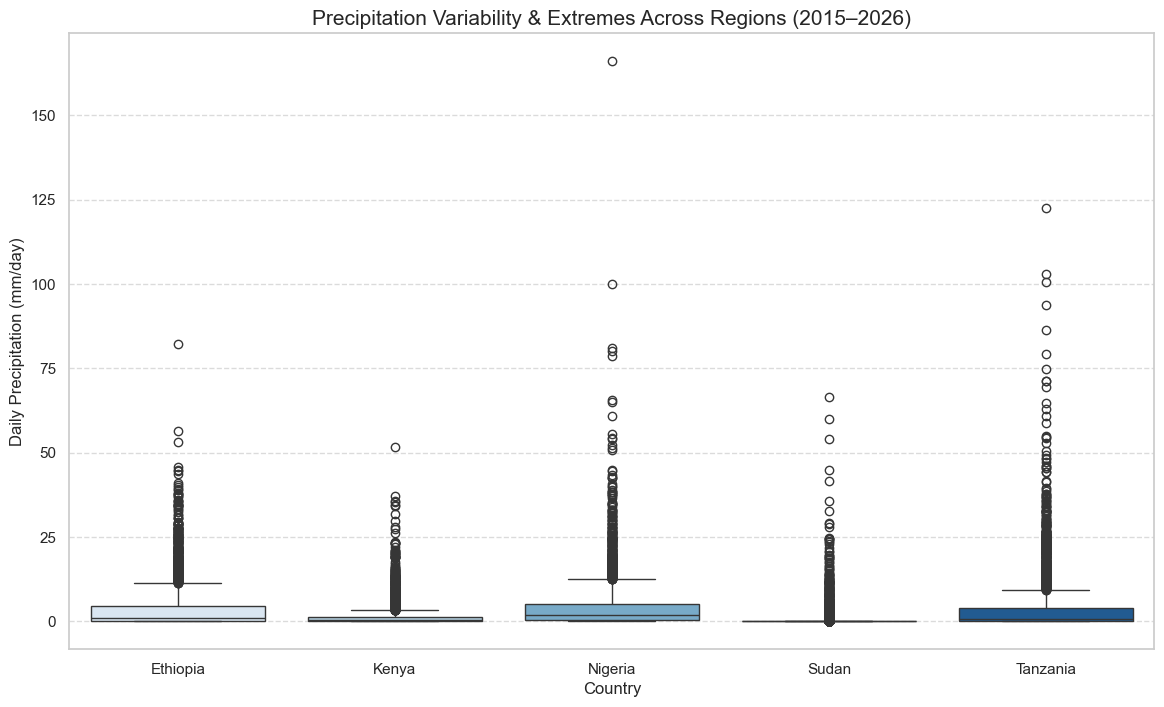


--- Precipitation Summary Statistics ---


,Mean Rain,Median Rain,Volatility (Std),Max Daily Event
Country,,,,
Tanzania,3.74,0.64,8.00,122.65
Nigeria,4.21,1.84,7.27,166.10
Ethiopia,3.63,0.82,6.29,82.30
Kenya,1.47,0.38,3.18,51.65
Sudan,0.64,0.00,3.06,66.49


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Path Setup
possible_folders = [".github/workflows", "../.github/workflows"]
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_dfs = []
valid_path = next((f for f in possible_folders if os.path.exists(f)), None)

if not valid_path:
    raise FileNotFoundError("Could not locate the .github/workflows folder.")

# 2. Load and Combine
for country in countries:
    file_path = os.path.join(valid_path, f"{country}.csv")
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path)
        temp_df['Country'] = country.capitalize()
        temp_df.replace(-999, pd.NA, inplace=True)
        all_dfs.append(temp_df)

combined_df = pd.concat(all_dfs)

# 3. Create Side-by-Side Boxplots
plt.figure(figsize=(14, 8))
sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', palette='Blues')

plt.title('Precipitation Variability & Extremes Across Regions (2015–2026)', fontsize=15)
plt.ylabel('Daily Precipitation (mm/day)')
plt.xlabel('Country')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Precipitation Stats Table
print("\n--- Precipitation Summary Statistics ---")
precip_summary = combined_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std', 'max']).round(2)
precip_summary.columns = ['Mean Rain', 'Median Rain', 'Volatility (Std)', 'Max Daily Event']
display(precip_summary.sort_values(by='Volatility (Std)', ascending=False))

Extreme Events: The "dots" above the boxes represent days of extreme rainfall. If a country has many dots high up (like Nigeria or Tanzania), they face a high flood risk.

The "Dry" Median: If the median (the line inside the box) is close to zero, it indicates that "no rain" is the most common daily state, which is typical for arid regions like Sudan.

Volatility (Std Dev): A high Standard Deviation in rainfall suggests that the rain is unpredictable—it comes in massive bursts rather than steady patterns. This is a critical insight for African agriculture.

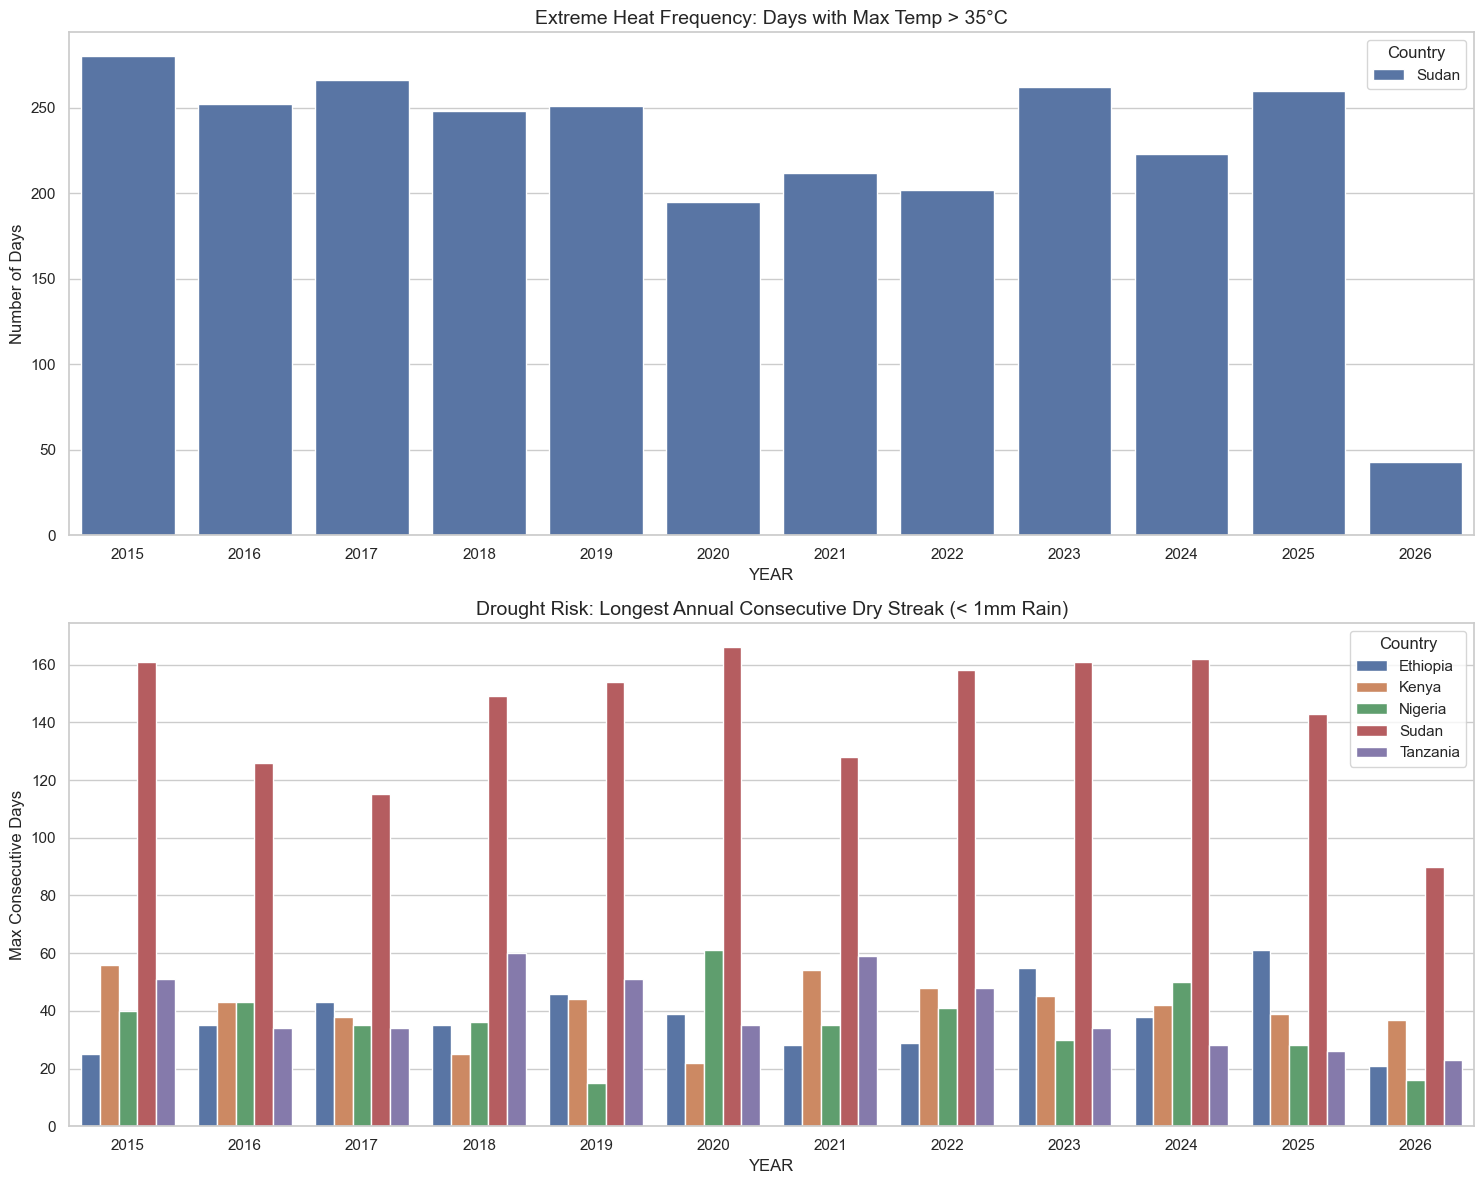


--- Extreme Event Summary (Max Values Observed) ---
          Max Heat Days/Year  Longest Dry Streak (Days)
Country                                                
Ethiopia                 NaN                         61
Kenya                    NaN                         56
Nigeria                  NaN                         61
Sudan                  280.0                        166
Tanzania                 NaN                         60


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# 1. Path Setup (using the folder found in the previous step)
valid_path = "../.github/workflows" # Based on your previous success
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_dfs = []

# 2. Load and Prepare Data
for country in countries:
    file_path = os.path.join(valid_path, f"{country}.csv")
    if os.path.exists(file_path):
        df_c = pd.read_csv(file_path)
        df_c['Country'] = country.capitalize()
        df_c.replace(-999, np.nan, inplace=True)
        all_dfs.append(df_c)

df_all = pd.concat(all_dfs)

# 3. Metric 1: Extreme Heat Days (T2M_MAX > 35°C)
heat_days = df_all[df_all['T2M_MAX'] > 35].groupby(['Country', 'YEAR']).size().reset_index(name='Count')

# 4. Metric 2: Max Consecutive Dry Days (PRECTOTCORR < 1mm)
def get_max_dry_streak(series):
    is_dry = series < 1
    # Identify groups of consecutive dry days
    streak_id = (is_dry != is_dry.shift()).cumsum()
    # Sum the dry days in each group and find the maximum
    return is_dry.groupby(streak_id).sum().max()

dry_streaks = df_all.groupby(['Country', 'YEAR'])['PRECTOTCORR'].apply(get_max_dry_streak).reset_index(name='Max_Streak')

# 5. Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Extreme Heat
sns.barplot(ax=axes[0], data=heat_days, x='YEAR', y='Count', hue='Country')
axes[0].set_title('Extreme Heat Frequency: Days with Max Temp > 35°C', fontsize=14)
axes[0].set_ylabel('Number of Days')

# Plot 2: Dry Streaks
sns.barplot(ax=axes[1], data=dry_streaks, x='YEAR', y='Max_Streak', hue='Country')
axes[1].set_title('Drought Risk: Longest Annual Consecutive Dry Streak (< 1mm Rain)', fontsize=14)
axes[1].set_ylabel('Max Consecutive Days')

plt.tight_layout()
plt.show()

# 6. Summary Statistics for Extreme Events
print("\n--- Extreme Event Summary (Max Values Observed) ---")
summary = pd.DataFrame({
    'Max Heat Days/Year': heat_days.groupby('Country')['Count'].max(),
    'Longest Dry Streak (Days)': dry_streaks.groupby('Country')['Max_Streak'].max()
})
print(summary)

Heat Vulnerability: If Sudan shows significantly higher bar heights in the first chart, it highlights a critical need for "Urban Heat Action Plans" and heat-resistant infrastructure.

Agricultural Resilience: The "Dry Streak" chart is essentially a drought map. Countries with streaks exceeding 100 days (like parts of the Sahel) require advanced irrigation strategies and drought-tolerant seed varieties.

Trends: Look for years where the bars for all countries are high (e.g., El Niño years). This proves that climate change is a regional, not just national, challenge.